# 01 — Business framing & data audit

Notebook khởi đầu của FaceKYC, chạy được trong **Colab runtime trống** và không phụ thuộc `src/`, `scripts/` hay artifact có sẵn.

**Quyết định cần hỗ trợ:** so sánh ảnh chân dung với selfie hiện tại (1:1 face verification), đồng thời sàng lọc presentation attack trước khi chuyển hồ sơ sang quy trình eKYC.

**Business rules ban đầu**

- Một observation verification là một cặp ảnh; output là decision support, không phải bằng chứng pháp lý về danh tính.
- False match là rủi ro an ninh; false non-match phải dẫn tới recapture/manual review, không tự động từ chối khách hàng.
- LFW là benchmark nghiên cứu, không đại diện cho ảnh giấy tờ hoặc dân số Việt Nam.
- PAD dùng synthetic print/replay proxy sinh từ LFW để có baseline tái lập. Nó không thay thế dataset PAD thật hay chứng nhận ISO/IEC 30107-3.
- Fold 9 và subject split `holdout` bị khóa đến notebook 05.


In [1]:
import os
import sys
import json
import random
import hashlib
import subprocess
from datetime import datetime, timezone
from pathlib import Path

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "scikit-learn>=1.5", "pandas>=2.2", "seaborn>=0.13",
    "opencv-python-headless>=4.10", "tqdm>=4.66",
])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter

SEED = 464
random.seed(SEED)
np.random.seed(SEED)

# A blank Colab runtime is the reference environment.  Nothing from src/ or
# scripts/ is needed.  All intermediate DS assets live under this runtime root.
RUNTIME_ROOT = Path("/content/facekyc_ds") if Path("/content").exists() else Path.cwd() / ".facekyc_ds"
DATA_ROOT = RUNTIME_ROOT / "data"
REPORT_ROOT = RUNTIME_ROOT / "reports"
ARTIFACT_ROOT = RUNTIME_ROOT / "artifacts"
for directory in (DATA_ROOT, REPORT_ROOT, ARTIFACT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

print("Runtime root:", RUNTIME_ROOT)
print("Python:", sys.version.split()[0])


Runtime root: /content/facekyc_ds
Python: 3.12.12


In [2]:
from sklearn.datasets import fetch_lfw_people

# This call downloads the official funneled LFW archive plus pair protocols.
_ = fetch_lfw_people(
    data_home=str(DATA_ROOT), color=True, resize=0.5,
    min_faces_per_person=0, download_if_missing=True,
)
LFW_HOME = DATA_ROOT / "lfw_home"
LFW_IMAGE_ROOT = LFW_HOME / "lfw_funneled"
assert LFW_IMAGE_ROOT.exists(), f"LFW extraction failed: {LFW_IMAGE_ROOT}"

def subject_bucket(subject):
    # Stable subject-level split: 80% train, 10% validation, 10% locked holdout.
    return int(hashlib.sha256(subject.encode("utf-8")).hexdigest()[:8], 16) % 10

def build_lfw_manifest():
    rows = []
    for path in sorted(LFW_IMAGE_ROOT.glob("*/*.jpg")):
        subject = path.parent.name
        bucket = subject_bucket(subject)
        split = "train" if bucket < 8 else ("validation" if bucket == 8 else "holdout")
        rows.append({"path": str(path), "subject": subject, "split": split})
    frame = pd.DataFrame(rows)
    assert len(frame) == 13233, f"Expected 13,233 LFW images, found {len(frame)}"
    assert frame.groupby("subject")["split"].nunique().max() == 1
    return frame

MANIFEST_PATH = DATA_ROOT / "lfw_subject_manifest.csv"
manifest = build_lfw_manifest()
manifest.to_csv(MANIFEST_PATH, index=False)
print("LFW images:", len(manifest), "subjects:", manifest.subject.nunique())


LFW images: 13233 subjects: 5749


## Audit cấu trúc dữ liệu và leakage


In [3]:
split_summary = manifest.groupby("split").agg(
    images=("path", "size"), subjects=("subject", "nunique")
).reindex(["train", "validation", "holdout"])
display(split_summary)

subject_overlap = {
    "train_validation": len(set(manifest.query("split == 'train'").subject) & set(manifest.query("split == 'validation'").subject)),
    "train_holdout": len(set(manifest.query("split == 'train'").subject) & set(manifest.query("split == 'holdout'").subject)),
    "validation_holdout": len(set(manifest.query("split == 'validation'").subject) & set(manifest.query("split == 'holdout'").subject)),
}
assert not any(subject_overlap.values()), subject_overlap

protocol = {}
for filename in ["pairsDevTrain.txt", "pairsDevTest.txt", "pairs.txt"]:
    protocol_path = LFW_HOME / filename
    with protocol_path.open(encoding="utf-8") as handle:
        header = next(handle).strip()
        rows = sum(1 for _ in handle)
    protocol[filename] = {"header": header, "pair_rows": rows}
pd.DataFrame(protocol).T


,images,subjects
split,,
train,10637,4619
validation,1592,596
holdout,1004,534


,header,pair_rows
pairsDevTrain.txt,1100,2200
pairsDevTest.txt,500,1000
pairs.txt,10\t300,6000


## EDA chỉ trên development data


,images_per_subject
count,5215.000000
mean,2.344966
std,9.420151
min,1.000000
50%,1.000000
90%,4.000000
99%,20.860000
max,530.000000


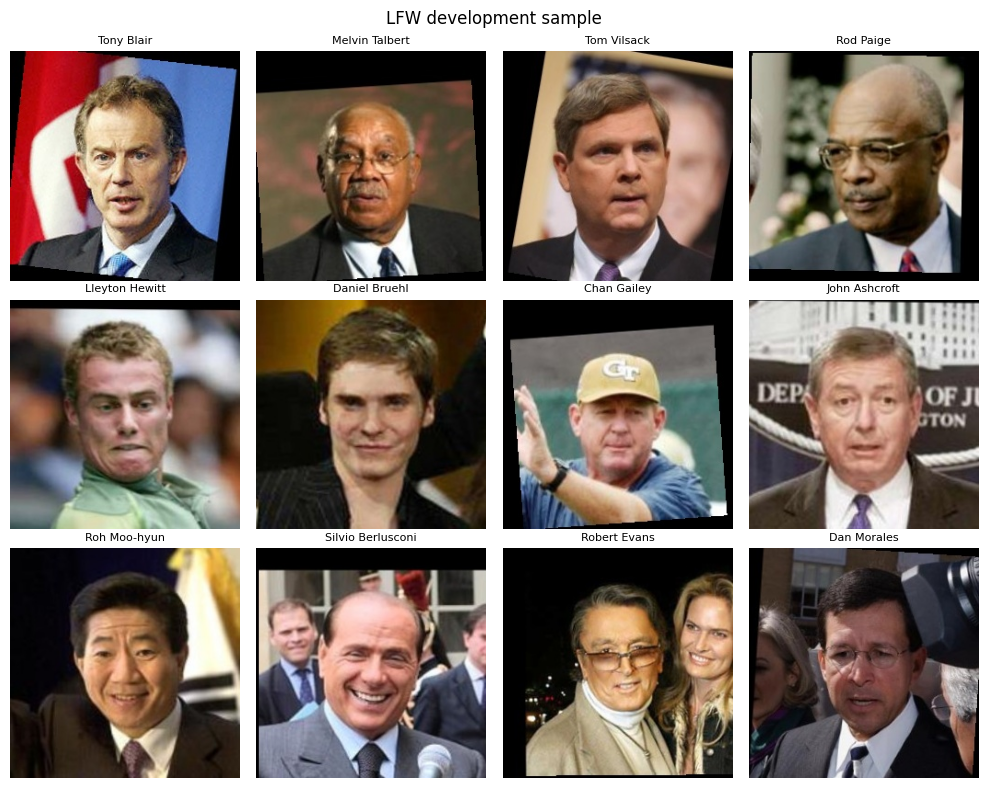

In [4]:
development = manifest.query("split != 'holdout'")
counts = development.groupby("subject").size()
display(counts.describe(percentiles=[0.5, 0.9, 0.99]).to_frame("images_per_subject"))

sample = development.sample(12, random_state=SEED)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for axis, row in zip(axes.ravel(), sample.itertuples()):
    with Image.open(row.path) as image:
        axis.imshow(image)
    axis.set_title(row.subject.replace("_", " "), fontsize=8)
    axis.axis("off")
plt.suptitle("LFW development sample")
plt.tight_layout()
plt.show()


In [5]:
report = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "business_unit": "one image pair per verification attempt",
    "verification_dataset": {"name": "LFW funneled", "official_pairs": protocol},
    "pad_dataset": {"name": "LFW-derived synthetic presentation-attack proxy", "real_pad_claim": False},
    "split_summary": split_summary.astype(int).to_dict("index"),
    "subject_overlap": subject_overlap,
    "production_claim": "research_decision_support_only",
    "holdout_accessed_for_modeling": False,
}
output = REPORT_ROOT / "01_data_audit.json"
output.write_text(json.dumps(report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
report


{'created_at': '2026-08-27T15:09:42.298454+00:00',
 'business_unit': 'one image pair per verification attempt',
 'verification_dataset': {'name': 'LFW funneled',
  'official_pairs': {'pairsDevTrain.txt': {'header': '1100',
    'pair_rows': 2200},
   'pairsDevTest.txt': {'header': '500', 'pair_rows': 1000},
   'pairs.txt': {'header': '10\t300', 'pair_rows': 6000}}},
 'pad_dataset': {'name': 'LFW-derived synthetic presentation-attack proxy',
  'real_pad_claim': False},
 'split_summary': {'train': {'images': 10637, 'subjects': 4619},
  'validation': {'images': 1592, 'subjects': 596},
  'holdout': {'images': 1004, 'subjects': 534}},
 'subject_overlap': {'train_validation': 0,
  'train_holdout': 0,
  'validation_holdout': 0},
 'production_claim': 'research_decision_support_only',
 'holdout_accessed_for_modeling': False}

## Kết luận sau khi chạy

Subject-level hashing loại bỏ overlap giữa train/validation/holdout. LFW có phân bố long-tail mạnh và không có camera, spoof medium hay demographic provenance đủ để đánh giá production fitness. Vì vậy các metric sau này chỉ là bằng chứng kỹ thuật cho baseline, chưa phải bằng chứng triển khai eKYC thực tế.
